In [18]:
import sys 
import os

if 'fast_shapelets' not in [el.split('/')[-1] for el in sys.path]:
    curr_path = os.getcwd()
    sys.path.append('/'.join((curr_path.split('/')[:-1])))




In [19]:
sys.path.insert(0,'../src') 
from _dataloader import get_dataset
from _fast_shapelet import FastShapelets
import numpy as np
import matplotlib.pyplot as plt

## Load data

In [3]:
def load_star_light_curves(data_dir="../data"):
    """
    Loads the StarLightCurves dataset directly from .txt files.
    
    Returns:
        X_train, y_train, X_test, y_test (all numpy arrays)
    """
    train_path = os.path.join(data_dir, "StarLightCurves_TRAIN.txt")
    test_path  = os.path.join(data_dir, "StarLightCurves_TEST.txt")
    
    # Load the raw data
    train_data = np.loadtxt(train_path)
    test_data  = np.loadtxt(test_path)
    
    # Split features and labels
    X_train = train_data[:, 1:]
    y_train = train_data[:, 0].astype(int) - 1  # subtract 1 to make labels 0-indexed
    X_test  = test_data[:, 1:]
    y_test  = test_data[:, 0].astype(int) - 1
    
    return X_train, y_train, X_test, y_test

In [20]:

def load_little_dataset(data_dir="../data"):
    """
    Loads the Little dataset from files with no extension.

    Returns:
        X_train, y_train, X_test, y_test (numpy arrays)
    """
    train_path = os.path.join(data_dir, "CBF_TRAIN")
    test_path  = os.path.join(data_dir, "CBF_TEST")

    # Load the raw data from extension-less files
    with open(train_path, "r") as f:
        train_data = np.loadtxt(f, delimiter=",")

    with open(test_path, "r") as f:
        test_data = np.loadtxt(f, delimiter=",")

    # Split features and labels
    X_train = train_data[:, 1:]
    y_train = train_data[:, 0].astype(int) - 1  # make labels 0-indexed

    X_test  = test_data[:, 1:]
    y_test  = test_data[:, 0].astype(int) - 1

    return X_train, y_train, X_test, y_test


In [21]:
#X_train, y_train, X_test, y_test = load_star_light_curves()
X_train, y_train, X_test, y_test = load_little_dataset()
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
# Now create your subsets
#X = X_train[:1000]
#y = y_train[:1000]
X = X_train
y = y_train

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X_train: (30, 128)
y_train: (30,)
X_test: (900, 128)
y_test: (900,)
X shape: (30, 128)
y shape: (30,)


Per-class statistics:
Class 0: n=10
Class 1: n=12
Class 2: n=8


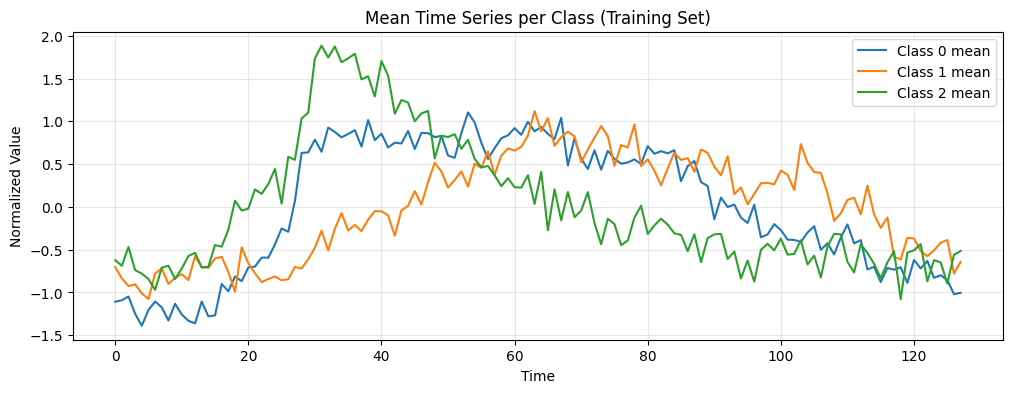

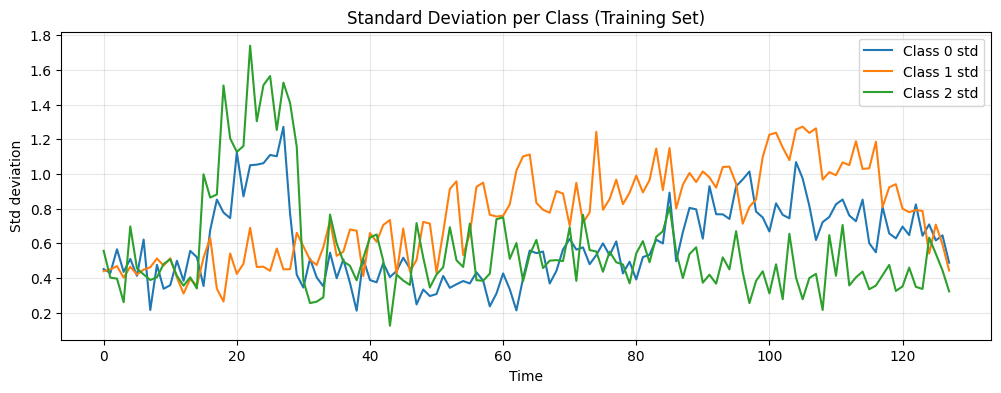

In [22]:

def compute_class_stats(X, y):
    """
    Compute mean and standard deviation time series for each class.
    
    Parameters
    ----------
    X : np.ndarray, shape (n_samples, time_length)
        Time series data
    y : np.ndarray, shape (n_samples,)
        Class labels (assumed integer encoded)
        
    Returns
    -------
    stats : dict
        stats[c]['mean'], stats[c]['std']
    """
    stats = {}
    classes = np.unique(y)

    for c in classes:
        X_c = X[y == c]
        stats[c] = {
            'mean': X_c.mean(axis=0),
            'std':  X_c.std(axis=0),
            'count': X_c.shape[0]
        }

    return stats


# ---- COMPUTE STATISTICS ----
stats = compute_class_stats(X_train, y_train)

# ---- PRINT SUMMARY ----
print("Per-class statistics:")
for c, d in stats.items():
    print(f"Class {c}: n={d['count']}")

# ---- OPTIONAL PLOT (GOOD FOR REPORT) ----
plt.figure(figsize=(12, 4))

for c, d in stats.items():
    plt.plot(d['mean'], label=f"Class {c} mean")

plt.title("Mean Time Series per Class (Training Set)")
plt.xlabel("Time")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(12, 4))

for c, d in stats.items():
    plt.plot(d['std'], label=f"Class {c} std")

plt.title("Standard Deviation per Class (Training Set)")
plt.xlabel("Time")
plt.ylabel("Std deviation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [30]:
fs = FastShapelets(shapelet_lengths=[30,60,80], cardinality=4, dimensionality=16, r=10)

In [26]:
import numpy as np

# Check the data types
print("Data types:")
print(f"X type: {type(X)}, dtype: {X.dtype}")
print(f"y type: {type(y)}, dtype: {y.dtype}")

# Check the actual content
print(f"X shape: {X.shape}")
print(f"Sample of X[0]: {X[0][:10]}")  # First 5 values of first sample
print(f"Sample of y: {y[:10]}")  # First 5 labels

# Convert to proper numeric types if needed
if X.dtype == object or not np.issubdtype(X.dtype, np.number):
    print("Converting X to float32...")
    X = X.astype(np.float32)

if y.dtype == object or not np.issubdtype(y.dtype, np.number):
    print("Converting y to int32...")
    y = y.astype(np.int32)

# Now check for NaN/inf values
print(f"NaN values in X: {np.isnan(X).sum()}")
print(f"Inf values in X: {np.isinf(X).sum()}")
print(f"NaN values in y: {np.isnan(y).sum()}")

# If there are NaN values, clean them
if np.isnan(X).sum() > 0:
    print("Cleaning NaN values...")
    valid_indices = ~np.isnan(X).any(axis=1)
    X = X[valid_indices]
    y = y[valid_indices]
    print(f"Cleaned X shape: {X.shape}")

print("Data ready for processing!")

Data types:
X type: <class 'numpy.ndarray'>, dtype: float64
y type: <class 'numpy.ndarray'>, dtype: int64
X shape: (30, 128)
Sample of X[0]: [-0.46428 -0.55505 -0.84284 -0.8659  -0.9364  -0.81727 -0.26361 -1.258
 -1.2504  -0.91831]
Sample of y: [0 0 0 2 1 1 0 2 1 0]
NaN values in X: 0
Inf values in X: 0
NaN values in y: 0
Data ready for processing!


## Fitting Fast Shapelet

In [6]:
import numpy as np
from _utils import scale as original_scale

# 1. Ensure all data is proper float32
X_train_conv = X_train.astype(np.float32)
X_test_conv = X_test.astype(np.float32)
X_conv = X.astype(np.float32)

print("Data types converted to float32")

Data types converted to float32


In [31]:
import numpy as np
from _utils import scale as original_scale

# 1. Ensure all data is proper float32
X_train_conv = X_train.astype(np.float32)
X_test_conv = X_test.astype(np.float32)
X_conv = X.astype(np.float32)

print("Data types converted to float32")

# 2. Replace the problematic scaling function
def robust_scale(X):
    """Robust scaling that ensures proper data types"""
    X = X.astype(np.float32)  # Ensure input is float32
    mu = X.mean(axis=-1, keepdims=True)
    sigma = X.std(axis=-1)
    sigma = np.where(sigma == 0, 1.0, sigma)  # Avoid division by zero
    return ((X - mu) / sigma[:, None]).astype(np.float32)

# Monkey patch the scaling function
import _utils as utils
utils.scale = robust_scale

print("Scaling function patched")

# 3. First fit the model (if not already done)
print("Fitting FastShapelets...")
fs.fit(X_conv, y)

# 4. Now transform the data
print("Transforming training data...")
#train_shap = fs.transform(X_train_conv[:1000])
train_shap = fs.transform(X_train_conv)
print("Transforming test data...") 
#test_shap = fs.transform(X_test_conv[:1000])
test_shap = fs.transform(X_test_conv)

print(f"train_shap shape: {train_shap.shape}")
print(f"test_shap shape: {test_shap.shape}")

c:\Users\Yani\Documents\fast_shapelets-main\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Computing all shapelets...

Computing shapelet 1/3

Data types converted to float32
Scaling function patched
Fitting FastShapelets...


Computing collision table...

...

Computing shapelet 3/3

Computing collision table...

Computing distances

Finding best shapelet

Transforming training data...
Transforming test data...
train_shap shape: (30, 3)
test_shap shape: (900, 3)


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# --- 1. Define the parameters to search ---
# It's common to test odd numbers to avoid ties in binary classification, 
# but test 1 through a reasonable limit (e.g., 11) for multi-class problems.
param_grid = {
    'n_neighbors': np.arange(1, 11) # Test k=1, 2, 3, ..., 11
}

# --- 2. Initialize the Grid Search ---
# We use the transformed training data and labels for tuning.
knn_base = KNeighborsClassifier()

# GridSearchCV uses k-fold CV internally (default is 5-fold)
grid_search = GridSearchCV(
    knn_base, 
    param_grid, 
    cv=5, # Use 5-fold cross-validation
    scoring='accuracy', 
    n_jobs=-1 # Use all available cores for speed
)

# --- 3. Perform the Search ---
print("Starting Grid Search for optimal n_neighbors...")
# Use your transformed training features and corresponding labels
grid_search.fit(train_shap, y_train[:1000]) 
#grid_search.fit(train_shap, y_train)

# --- 4. Get the Results ---
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print(f"\nOptimal n_neighbors found: {best_k}")
print(f"Mean cross-validation accuracy with k={best_k}: {best_score:.4f}")

# --- 5. Final Model Evaluation ---
# Now, use the best_k to train the final model and test it on the unseen data (test_shap)
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(train_shap, y_train[:1000])
#final_knn.fit(train_shap, y_train)

test_score = final_knn.score(test_shap, y_test[:1000])
#test_score = final_knn.score(test_shap, y_test)
print(f"Final Test Set Accuracy with optimal k: {test_score:.4f}")

Starting Grid Search for optimal n_neighbors...

Optimal n_neighbors found: 1
Mean cross-validation accuracy with k=1: 1.0000
Final Test Set Accuracy with optimal k: 0.9978


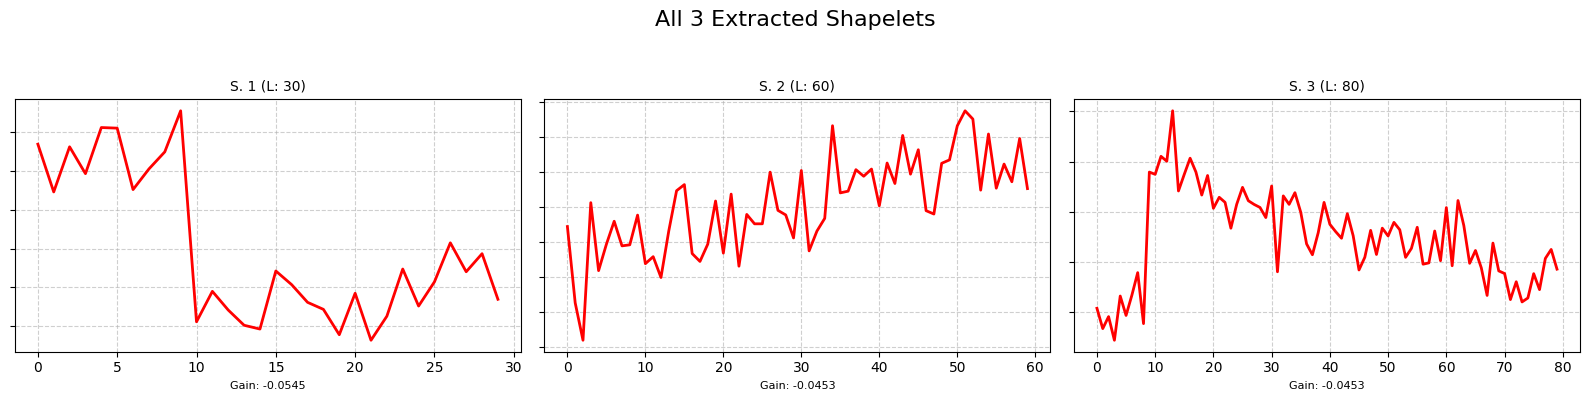

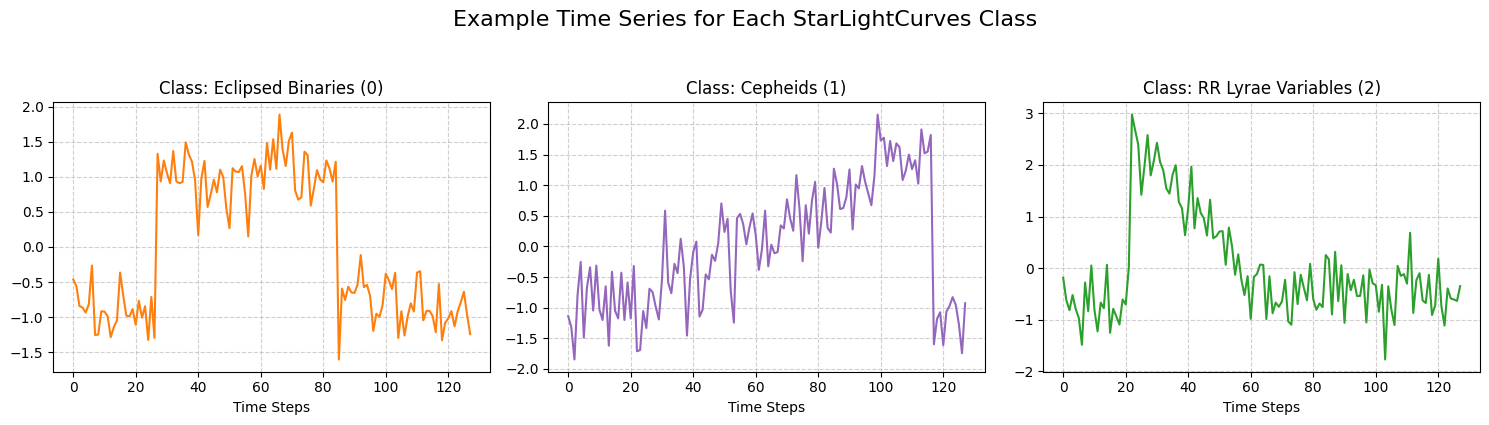

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import math

# --- Data Extraction & Preparation ---
# Get ALL extracted shapelets (N)
# This assumes 'fs' has been fitted (e.g., fs.fit(X, y) was run)
extracted_shapelets = fs.get_shapelets()
shapelet_items = list(extracted_shapelets.items())
N = len(shapelet_items) # Total number of shapelets found

# Define the number of columns for the plot grid (adjust for best viewing)
MAX_COLS = 4 
ncols = min(N, MAX_COLS)
nrows = math.ceil(N / ncols)

# Find one sample index for each class (0, 1, 2) in the training subset X
class_labels = np.unique(y) # Assumes labels are 0, 1, 2 for StarLightCurves
example_indices = {}
for cls in class_labels:
    example_indices[cls] = np.where(y == cls)[0][0]

# Map the 0-indexed labels back to the star types
STAR_CLASSES = [
    "Eclipsed Binaries (0)", 
    "Cepheids (1)", 
    "RR Lyrae Variables (2)"
]
colors = ['#ff7f0e', '#9467bd', '#2ca02c'] # Consistent colors for classes

# --- Figure 1: All Extracted Shapelets (Dynamic Layout) ---

fig1, axes1 = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
fig1.suptitle(f"All {N} Extracted Shapelets", fontsize=16, y=1.02)

# Flatten axes array for easy iteration
axes1 = axes1.flatten() 

for i, (length, shapelet_obj) in enumerate(shapelet_items):
    ax = axes1[i]
    # Plot the shapelet value
    ax.plot(shapelet_obj.value, color='red', linewidth=2)
    
    # Add info about the shapelet (Length, Gain/Gap)
    ax.set_title(f"S. {i+1} (L: {length})", fontsize=10)
    ax.set_xlabel(f"Gain: {shapelet_obj.gain:.4f}", fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='y', labelleft=False)

# Hide any unused subplots
for j in range(i + 1, nrows * ncols):
    fig1.delaxes(axes1[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.97])


# --- Figure 2: Time Series Class Examples (Fixed 1x3 Layout) ---
fig2, axes2 = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
fig2.suptitle("Example Time Series for Each StarLightCurves Class", fontsize=16, y=1.05)

for i, cls in enumerate(class_labels):
    ax = axes2[i]
    idx = example_indices[cls]
    
    # Plot the time series example
    ax.plot(X[idx], color=colors[i], linewidth=1.5) 
    
    # Label the plot
    ax.set_title(f"Class: {STAR_CLASSES[cls]}", fontsize=12)
    ax.set_xlabel("Time Steps")
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Hyperparameters Experiments

In [11]:
import itertools
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from _fast_shapelet import FastShapelets

def run_fastshapelet_grid_search(
    X_train, y_train,
    X_test, y_test,
    shapelet_lengths_grid,
    dimensionality_grid,
    cardinality_grid,
    r_grid,
    subset_size=1000
):
    """
    Run experiments over a grid of FastShapelet hyperparameters and return results as a DataFrame.

    Parameters
    ----------
    X_train, y_train : training data
    X_test, y_test : test data
    shapelet_lengths_grid : list of lists of shapelet lengths
    dimensionality_grid : list of integers
    cardinality_grid : list of integers
    r_grid : list of integers
    subset_size : int, optional
        Number of samples to use for fitting and evaluation (default 1000)

    Returns
    -------
    results_df : pd.DataFrame
        Sorted dataframe with experiment parameters and metrics
    """

    results = []
    experiment_id = 1

    for shap_lens, dim, card, r in itertools.product(
        shapelet_lengths_grid,
        dimensionality_grid,
        cardinality_grid,
        r_grid
    ):
        print(f"\n========== Experiment {experiment_id} ==========")
        print(f"shapelet_lengths = {shap_lens}")
        print(f"dimensionality   = {dim}")
        print(f"cardinality      = {card}")
        print(f"r                = {r}")

        # 1. Create FastShapelets model
        fs = FastShapelets(
            shapelet_lengths=shap_lens,
            dimensionality=dim,
            cardinality=card,
            r=r
        )

        # 2. Fit on a subset
        fs.fit(X_train[:subset_size], y_train[:subset_size])

        # 3. Transform training/test sets
        train_shap = fs.transform(X_train[:subset_size])
        test_shap  = fs.transform(X_test[:subset_size])

        # 4. Tune k-NN
        grid = GridSearchCV(
            KNeighborsClassifier(),
            {'n_neighbors': np.arange(1, 11)},
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(train_shap, y_train[:subset_size])

        best_k = grid.best_params_['n_neighbors']
        cv_score = grid.best_score_

        # 5. Evaluate on test
        final_knn = KNeighborsClassifier(n_neighbors=best_k)
        final_knn.fit(train_shap, y_train[:subset_size])
        test_acc = final_knn.score(test_shap, y_test[:subset_size])

        # 6. Save results
        results.append({
            'experiment': experiment_id,
            'shapelet_lengths': str(shap_lens),
            'dimensionality': dim,
            'cardinality': card,
            'r': r,
            'best_k': best_k,
            'cv_accuracy': cv_score,
            'test_accuracy': test_acc
        })

        experiment_id += 1

    # Compile results into DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='test_accuracy', ascending=False).reset_index(drop=True)
    
    return results_df



In [12]:
results_df = run_fastshapelet_grid_search(
    X_train, y_train,
    X_test, y_test,
    shapelet_lengths_grid=[ [300,400]],
    dimensionality_grid=[ 16],
    cardinality_grid=[3, 4, 6, 8, 12],
    r_grid=[5],
    subset_size=1000
)
results_df = results_df.sort_values(by='test_accuracy', ascending=False)
results_df.to_csv("../starlight_experiment_cardinality_results.csv", index=False)

c:\Users\Yani\Documents\fast_shapelets-main\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Computing all shapelets...

Computing shapelet 1/2


========== Experiment 1 ==========
shapelet_lengths = [300, 400]
dimensionality   = 16
cardinality      = 3
r                = 5


Computing collision table...

...

Computing all shapelets...

Computing shapelet 1/2


========== Experiment 3 ==========
shapelet_lengths = [300, 400]
dimensionality   = 16
cardinality      = 6
r                = 5


Computing collision table...

JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory allocating 19114607160 bytes.

In [ ]:
results_df=pd.read_csv("../starlight_experiment_cardinality_results.csv")


In [11]:
# =========================
# Embed time series in shapelet-distance space (UMAP + t-SNE)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.manifold import TSNE
import pandas as pd

sns.set(style="whitegrid", font_scale=1.1)

# --- PARAMETERS ---
N = 1000                      # number of series to embed (use <= len(X_train))
use_pca = True                # whether to run PCA before t-SNE
pca_dims = 50                 # PCA dims if many shapelets
random_state = 42

# --- compute shapelet-distance features ---
# fs must be fitted. We'll use the first N train series and optionally first N test series.
fs.fit(X_train[:N].astype(np.float32), y_train[:N])

X_emb_train = fs.transform(X_train[:N].astype(np.float32))  # shape: (N, n_shapelets)
y_emb_train = y_train[:N]

print("Feature matrix shape:", X_emb_train.shape)

# --- scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_emb_train)

# --- optional PCA for t-SNE stability ---
if use_pca and X_scaled.shape[1] > pca_dims:
    pca = PCA(n_components=pca_dims, random_state=random_state)
    X_for_tsne = pca.fit_transform(X_scaled)
    print(f"PCA reduced features to: {X_for_tsne.shape}")
else:
    X_for_tsne = X_scaled

# --- UMAP embedding ---
print("Computing UMAP...")
umap_emb = UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=random_state).fit_transform(X_scaled)

# --- t-SNE embedding (use X_for_tsne to speed up when many dims) ---
print("Computing t-SNE (may take some time)...")
tsne_emb = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=random_state).fit_transform(X_for_tsne)

# --- Build a DataFrame for easy plotting ---
df_umap = pd.DataFrame({"x": umap_emb[:,0], "y": umap_emb[:,1], "class": y_emb_train})
df_tsne = pd.DataFrame({"x": tsne_emb[:,0], "y": tsne_emb[:,1], "class": y_emb_train})

CLASS_NAMES = {
    0: "Eclipsed Binaries (0)",
    1: "Cepheids (1)",
    2: "RR Lyrae (2)"
}

# --- Plot function ---
def plot_embedding(df, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df, x="x", y="y", hue="class", palette="tab10", s=30, alpha=0.8, legend="full")
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("")
    plt.legend(title="Class", labels=[CLASS_NAMES.get(i, str(i)) for i in sorted(df["class"].unique())])
    plt.tight_layout()
    plt.show()

# --- Show UMAP and t-SNE ---
plot_embedding(df_umap, "UMAP of time series in shapelet-distance space")
plot_embedding(df_tsne, "t-SNE of time series in shapelet-distance space")

# --- Optional: find which shapelets correlate with first UMAP axis ---
from scipy.stats import pearsonr

features = fs.get_shapelets()                # dict length = n_shapelets (keys = lengths in your current implementation)
shapelet_keys = list(features.keys())        # names/lengths (may be small ints)
# Ensure features are ordered same as fs.transform produced them.
# Here transform() returns distances in the order of fs.get_shapelets().values() used in transform implementation.
# We'll assume that ordering matches list(features.values()) — if not, adapt accordingly.

# compute correlations between each feature column and umap x
corrs = []
for i in range(X_scaled.shape[1]):
    r, p = pearsonr(X_scaled[:, i], umap_emb[:, 0])
    corrs.append((i, r, p))

# get top positive and negative correlates
corrs_sorted = sorted(corrs, key=lambda x: -abs(x[1]))
topk = 8
print(f"Top {topk} shapelet features most correlated with UMAP axis 0:")
for idx, r, p in corrs_sorted[:topk]:
    # try to name the shapelet
    name = shapelet_keys[idx] if idx < len(shapelet_keys) else f"feat_{idx}"
    print(f"  feature #{idx} (shapelet key: {name}): r={r:.3f}, p={p:.3e}")

# --- Optional: visualize average time series in two clusters ---
# Use simple kmeans on embedding to pick two clusters for visualization
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=random_state).fit(umap_emb)
labels = kmeans.labels_

# For each cluster show mean distance profile (feature space) and a few example series
for c in np.unique(labels):
    idxs = np.where(labels == c)[0]
    print(f"Cluster {c}: size {len(idxs)} (showing up to 3 example time series)")
    examples = idxs[:3]
    plt.figure(figsize=(10,3))
    for j in examples:
        plt.plot(X_train[j], alpha=0.8)
    plt.title(f"Examples from cluster {c}")
    plt.show()


c:\Users\Yani\Documents\fast_shapelets-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\Yani\Documents\fast_shapelets-main\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Computing all shapelets...

Computing shapelet 1/3

Computing collision table...

JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory allocating 1602920496 bytes.